In [1]:
import os
from pathlib import Path

# === 1) SET KREDENSIAL (sekali aja) ===

os.environ["KAGGLE_USERNAME"] = "adityaakbar"
os.environ["KAGGLE_KEY"]      = "8868d5e13295a0e896b3a4f7d352936e"

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kaggle"])
    from kaggle.api.kaggle_api_extended import KaggleApi


api = KaggleApi()
api.authenticate()

project_root = Path().resolve()          # folder tempat notebook berada (cwd)
target_dir   = project_root / "data"
target_dir.mkdir(parents=True, exist_ok=True)
print("Target dir:", target_dir)

# ini akan download ZIP dan langsung unzip ke target_dir
api.dataset_download_files(
    dataset="awsaf49/brats20-dataset-training-validation",
    path=str(target_dir),
    unzip=True
)

print("Selesai. Cek folder:", target_dir)


Target dir: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data
Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
Selesai. Cek folder: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data


# Unet++ MedicalNet WarmUp Lr Encoder & Decoder

In [1]:
import os, math, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, EnsureTyped, Compose, SelectItemsd,
    NormalizeIntensityd, CropForegroundd, RandSpatialCropd,
    RandScaleIntensityd, RandShiftIntensityd, RandFlipd, ConcatItemsd, MapTransform
)
from monai.inferers import sliding_window_inference

def log(*a): print(*a, flush=True)

PROJECT_ROOT = Path().resolve()                    # selevel notebook
DATA_ROOT    = PROJECT_ROOT / "data"
# --- KONFIG ---
MAIN_DIR   = DATA_ROOT  # ganti path sesuai datasetmu
BATCH_SIZE = 1                                  # aman di T4 dengan patch 128^3
NUM_WORKERS= 2
ROI = (128, 128, 128)

/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/module.py:396: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


In [3]:
import os
from pathlib import Path

PROJECT_ROOT = Path().resolve()
DATA_ROOT    = PROJECT_ROOT / "data"   # kamu bilang sekarang langsung "data"

def looks_like_patient_dir(p: Path) -> bool:
    if not p.is_dir(): return False
    need = ["flair","t1","t1ce","t2","seg"]
    found = 0
    for suf in need:
        if list(p.glob(f"*_{suf}.nii*")):
            found += 1
    return found == len(need)

def auto_find_main_dir(data_root: Path) -> str:
    # 1) data_root → apakah langsung berisi folder pasien?
    subs = [x for x in data_root.iterdir() if x.is_dir()]
    if any(looks_like_patient_dir(x) for x in subs):
        return str(data_root)
    # 2) satu tingkat di bawah
    for sub in subs:
        subs2 = [x for x in sub.iterdir() if x.is_dir()]
        if any(looks_like_patient_dir(x) for x in subs2):
            return str(sub)
    # 3) fallback: cari lebih dalam
    for sub in data_root.rglob("*"):
        if sub.is_dir():
            subs3 = [x for x in sub.iterdir() if x.is_dir()]
            if any(looks_like_patient_dir(x) for x in subs3):
                return str(sub)
    raise RuntimeError(f"Tidak menemukan folder pasien di bawah: {data_root}")

MAIN_DIR = auto_find_main_dir(DATA_ROOT)
print("MAIN_DIR =", MAIN_DIR)

# intip 1 folder pasien & isinya
sample_pat = next((d for d in Path(MAIN_DIR).iterdir() if d.is_dir()), None)
if sample_pat:
    print("Contoh folder pasien:", sample_pat.name)
    print("Contoh file:",
          [p.name for p in sample_pat.glob("*.nii*")])


MAIN_DIR = /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Contoh folder pasien: BraTS20_Training_115
Contoh file: ['BraTS20_Training_115_t1.nii', 'BraTS20_Training_115_seg.nii', 'BraTS20_Training_115_t2.nii', 'BraTS20_Training_115_flair.nii', 'BraTS20_Training_115_t1ce.nii']


In [4]:
def get_data_paths(data_dir):
    def find_file(folder, pid, suffix):
        for ext in (".nii.gz", ".nii"):
            p = os.path.join(folder, f"{pid}_{suffix}{ext}")
            if os.path.exists(p): return p
        return None

    data_paths = []
    print(f"Scanning dataset dir: {data_dir}")
    for pid in sorted(os.listdir(data_dir)):
        pdir = os.path.join(data_dir, pid)
        if not os.path.isdir(pdir): continue
        flair = find_file(pdir, pid, "flair")
        t1    = find_file(pdir, pid, "t1")
        t1gd  = find_file(pdir, pid, "t1ce")
        t2    = find_file(pdir, pid, "t2")
        seg   = find_file(pdir, pid, "seg")
        if all([flair, t1, t1gd, t2, seg]):
            data_paths.append({"flair":flair, "t1":t1, "t1gd":t1gd, "t2":t2, "label":seg, "pid":pid})
    print(f"Found {len(data_paths)} samples.")
    return data_paths

all_paths = get_data_paths(MAIN_DIR)
if not all_paths:
    raise RuntimeError("No data found. Check MAIN_DIR & filenames.")


Scanning dataset dir: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Found 368 samples.


In [5]:
class BraTSLabelToETTCWT(MapTransform):
    """
    Input d["label"] shape [1,D,H,W] atau [D,H,W] berisi {0,1,2,4}.
    Output d["label_ettcwt"] shape [3,D,H,W]: [ET, TC, WT] sebagai mask biner.
    """
    def __init__(self, keys=("label",), out_key="label_ettcwt"):
        super().__init__(keys); self.out_key = out_key

    def __call__(self, data):
        d = dict(data)
        lab = d[self.keys[0]]
        lab = torch.as_tensor(lab)
        if lab.ndim == 4 and lab.shape[0] == 1: lab = lab[0]  # [D,H,W]
        et = (lab == 4).float()
        tc = ((lab == 1) | (lab == 4)).float()
        wt = ((lab == 1) | (lab == 2) | (lab == 4)).float()
        d[self.out_key] = torch.stack([et, tc, wt], dim=0)  # [3,D,H,W]
        return d

In [6]:
P_RESCALE = 0.20
P_SHIFT   = 0.20
P_FLIP    = 0.50

train_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=True, random_size=False),
    # label → 3C multi-label
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
    # augmentasi B
    RandScaleIntensityd(keys="image", factors=0.1, prob=P_RESCALE),  # ×U[0.9,1.1]
    RandShiftIntensityd(keys="image", offsets=0.1, prob=P_SHIFT),    # +U[-0.1,0.1]
    RandFlipd(keys=["image","label_ettcwt"], prob=P_FLIP, spatial_axis=[0,1,2]),
])

val_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=False, random_size=False),
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
])


/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [7]:
class BraTSDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = list(items); self.tx = transform
        if not self.items: raise ValueError("Empty dataset")
    def __len__(self): return len(self.items)
    def __getitem__(self, i): 
        s = self.items[i]
        return self.tx(s) if self.tx else s

rng = np.random.RandomState(42)
perm = rng.permutation(len(all_paths))
all_paths = [all_paths[i] for i in perm]
cut = int(0.8*len(all_paths))
train_ds = BraTSDataset(all_paths[:cut], transform=train_transforms)
val_ds   = BraTSDataset(all_paths[cut:],  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

log(f"Loaders OK | train={len(train_ds)} val={len(val_ds)} bs={BATCH_SIZE}")

Loaders OK | train=294 val=74 bs=1


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F, re
import monai.networks.nets.resnet as monai_resnet
from monai.networks.layers.factories import Conv
from monai.networks.nets.basic_unet import TwoConv, UpCat


def prepare_medicalnet_state_for_monai(sd_in, in_channels=4):
    sd_raw = sd_in.get("state_dict", sd_in)
    sd = dict(sd_raw)
    remap = {}

    for k, v in sd.items():
        kk = k[len("module."):] if k.startswith("module.") else k

        # drop classifier
        if kk.startswith("fc."):
            continue

        # strip inner ".conv" (varian yang simpan conv submodule)
        kk = kk.replace(".conv1.conv.", ".conv1.")
        kk = kk.replace(".conv2.conv.", ".conv2.")
        kk = kk.replace(".conv3.conv.", ".conv3.")  # aman utk R50 juga

        # map style 'downsample.conv/bn' → 'downsample.0/1'
        kk = kk.replace(".downsample.conv.", ".downsample.0.")
        kk = kk.replace(".downsample.bn.",  ".downsample.1.")

        # map style 'shortcut' → 'downsample'
        kk = kk.replace(".shortcut.0.", ".downsample.0.")
        kk = kk.replace(".shortcut.1.", ".downsample.1.")

        # sebagian ckpt pakai 'downsample.weight' (tanpa .0) → asumsi conv
        if ".downsample.weight" in kk and ".downsample.0.weight" not in kk:
            kk = kk.replace(".downsample.weight", ".downsample.0.weight")
        if ".downsample.bias" in kk and ".downsample.0.bias" not in kk:
            kk = kk.replace(".downsample.bias", ".downsample.0.bias")

        remap[kk] = v

    # adapt conv1 Cin=1 → multi-modal (mis. 4)
    for conv1_key in ["conv1.weight", "conv1.conv.weight"]:
        if conv1_key in remap:
            w = remap[conv1_key]
            if w.ndim == 5 and w.shape[1] == 1 and in_channels > 1:
                w = w.mean(1, keepdim=True).repeat(1, in_channels, 1, 1, 1) / float(in_channels)
                remap[conv1_key] = w
                break

    return remap


@torch.no_grad()
def load_medicalnet_into_monai_resnet(backbone, pth_path, in_channels=4, verbose=True):
    raw = torch.load(pth_path, map_location="cpu")
    sd  = prepare_medicalnet_state_for_monai(raw, in_channels=in_channels)
    info = backbone.load_state_dict(sd, strict=False)
    try:
        missing, unexpected = info.missing_keys, info.unexpected_keys
    except AttributeError:
        missing, unexpected = info
    if verbose:
        monai_keys = backbone.state_dict()
        matched = sum(int(k in monai_keys and monai_keys[k].shape == sd[k].shape) for k in sd.keys())
        print(f"[MedicalNet→MONAI] matched={matched}  missing={len(missing)}  unexpected={len(unexpected)}")
    return info


class MedicalNetResNet18Encoder(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.backbone = monai_resnet.resnet18(
            spatial_dims=3, n_input_channels=in_channels, pretrained=False, progress=False
        )
        self.layer1 = self.backbone.layer1
        self.layer2 = self.backbone.layer2
        self.layer3 = self.backbone.layer3
        self.layer4 = self.backbone.layer4

    @torch.no_grad()
    def load_medicalnet_pretrain(self, pth_path, in_channels=4):
        load_medicalnet_into_monai_resnet(
            backbone=self.backbone, pth_path=pth_path, in_channels=in_channels, verbose=True
        )

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = F.relu(x, inplace=True)
        s0 = x                 # <<< /2 tap (SEBELUM maxpool)
        x  = self.backbone.maxpool(x)
        s1 = self.layer1(x)    # /4
        s2 = self.layer2(s1)   # /8
        s3 = self.layer3(s2)   # /16
        # s4 = self.layer4(s3) # /32 (TIDAK dipakai di UNet++ 5-level)
        return s0, s1, s2, s3

class UNetPP3D_Decoder(nn.Module):
    def __init__(
        self,
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
        features=(16,32,64,128,128,16),
        act=("LeakyReLU", {"negative_slope": 0.1, "inplace": True}),
        norm=("instance", {"affine": True}),
        dropout=0.0,
        upsample="nontrainable",
        enc_channels=(64,128,256,512),
        deep_supervision=True,
    ):
        super().__init__()
        self.deep_supervision = deep_supervision
        F0,F1,F2,F3,F4,Fhead = features
        Conv1x1 = lambda a,b: Conv["conv", spatial_dims](a, b, kernel_size=1, bias=False)

        self.conv_0_0 = TwoConv(spatial_dims, in_channels, F0, act, norm, True, dropout)

        self.enc_adapt1 = Conv1x1(enc_channels[0], F1)
        self.enc_adapt2 = Conv1x1(enc_channels[1], F2)
        self.enc_adapt3 = Conv1x1(enc_channels[2], F3)
        self.enc_adapt4 = Conv1x1(enc_channels[3], F4)

        self.upcat_0_1 = UpCat(spatial_dims, F1, F0, F0, act, norm, True, dropout, upsample, halves=False)
        self.upcat_1_1 = UpCat(spatial_dims, F2, F1, F1, act, norm, True, dropout, upsample)
        self.upcat_2_1 = UpCat(spatial_dims, F3, F2, F2, act, norm, True, dropout, upsample)
        self.upcat_3_1 = UpCat(spatial_dims, F4, F3, F3, act, norm, True, dropout, upsample)

        self.upcat_0_2 = UpCat(spatial_dims, F1, F0*2, F0, act, norm, True, dropout, upsample, halves=False)
        self.upcat_1_2 = UpCat(spatial_dims, F2, F1*2, F1, act, norm, True, dropout, upsample)
        self.upcat_2_2 = UpCat(spatial_dims, F3, F2*2, F2, act, norm, True, dropout, upsample)

        self.upcat_0_3 = UpCat(spatial_dims, F1, F0*3, F0, act, norm, True, dropout, upsample, halves=False)
        self.upcat_1_3 = UpCat(spatial_dims, F2, F1*3, F1, act, norm, True, dropout, upsample)

        self.upcat_0_4 = UpCat(spatial_dims, F1, F0*4, Fhead, act, norm, True, dropout, upsample, halves=False)

        self.final_conv_0_1 = Conv["conv", spatial_dims](F0,    out_channels, kernel_size=1)
        self.final_conv_0_2 = Conv["conv", spatial_dims](F0,    out_channels, kernel_size=1)
        self.final_conv_0_3 = Conv["conv", spatial_dims](F0,    out_channels, kernel_size=1)
        self.final_conv_0_4 = Conv["conv", spatial_dims](Fhead, out_channels, kernel_size=1)

    def forward(self, x, feats):
        # feats dari encoder ResNet18: s0(~ /2), s1(~ /4), s2(~ /8), s3(~ /16)
        s0, s1, s2, s3 = feats
    
        # adapt channel
        s0 = self.enc_adapt1(s0)
        s1 = self.enc_adapt2(s1)
        s2 = self.enc_adapt3(s2)
        s3 = self.enc_adapt4(s3)
    
        # --- NORMALISASI SPASIAL: pastikan tepat /2, /4, /8, /16 dr input ---
        x_0_0 = self.conv_0_0(x)         # /1 (dimensi sama dgn input)
        D, H, W = x_0_0.shape[2:]
        size_1  = (max(1, D // 2),  max(1, H // 2),  max(1, W // 2))   # /2
        size_2  = (max(1, D // 4),  max(1, H // 4),  max(1, W // 4))   # /4
        size_3  = (max(1, D // 8),  max(1, H // 8),  max(1, W // 8))   # /8
        size_4  = (max(1, D // 16), max(1, H // 16), max(1, W // 16))  # /16
    
        s0 = F.interpolate(s0, size=size_1, mode="trilinear", align_corners=False)
        s1 = F.interpolate(s1, size=size_2, mode="trilinear", align_corners=False)
        s2 = F.interpolate(s2, size=size_3, mode="trilinear", align_corners=False)
        s3 = F.interpolate(s3, size=size_4, mode="trilinear", align_corners=False)
    
        # --- UNet++ grid (DS ON) ---
        # level-1 (target /1): up(sample /2) + skip /1
        x_1_0 = s0
        x_0_1 = self.upcat_0_1(x_1_0, x_0_0)
    
        # level-2
        x_2_0 = s1
        x_1_1 = self.upcat_1_1(x_2_0, x_1_0)
        x_0_2 = self.upcat_0_2(x_1_1, torch.cat([x_0_0, x_0_1], dim=1))
    
        # level-3
        x_3_0 = s2
        x_2_1 = self.upcat_2_1(x_3_0, x_2_0)
        x_1_2 = self.upcat_1_2(x_2_1, torch.cat([x_1_0, x_1_1], dim=1))
        x_0_3 = self.upcat_0_3(x_1_2, torch.cat([x_0_0, x_0_1, x_0_2], dim=1))
    
        # level-4 (terdalam /16)
        x_4_0 = s3
        x_3_1 = self.upcat_3_1(x_4_0, x_3_0)
        x_2_2 = self.upcat_2_2(x_3_1, torch.cat([x_2_0, x_2_1], dim=1))
        x_1_3 = self.upcat_1_3(x_2_2, torch.cat([x_1_0, x_1_1, x_1_2], dim=1))
        x_0_4 = self.upcat_0_4(x_1_3, torch.cat([x_0_0, x_0_1, x_0_2, x_0_3], dim=1))
    
        y_0_1 = self.final_conv_0_1(x_0_1)
        y_0_2 = self.final_conv_0_2(x_0_2)
        y_0_3 = self.final_conv_0_3(x_0_3)
        y_0_4 = self.final_conv_0_4(x_0_4)

        if self.deep_supervision:
            return [y_0_4, y_0_3, y_0_2, y_0_1] if self.training else y_0_4
        else:
            return y_0_4

class UNetPP3D_MedicalNet(nn.Module):
    def __init__(self,
        in_channels=4,
        out_channels=3,                   # ET/TC/WT (multi-label → sigmoid di loss)
        features=(16,32,64,128,128,16),   # kecil, aman T4
        enc_channels=(64,128,256,512),    # taps ResNet18
    ):
        super().__init__()
        self.encoder = MedicalNetResNet18Encoder(in_channels=in_channels)
        self.decoder = UNetPP3D_Decoder(
            spatial_dims=3,
            in_channels=in_channels,
            out_channels=out_channels,
            features=features,
            enc_channels=enc_channels,
            upsample="nontrainable",
            deep_supervision=True,
        )

    def load_medicalnet(self, pth_path):
        self.encoder.load_medicalnet_pretrain(
            pth_path=pth_path,
            in_channels=self.encoder.backbone.conv1.in_channels,
        )

    def forward(self, x):
        feats = self.encoder(x)
        return self.decoder(x, feats)


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNetPP3D_MedicalNet(
        in_channels=4,            # FLAIR,T1,T1ce,T2
        out_channels=3,           # ET/TC/WT (multi-label → sigmoid di loss)
        features=(16,32,64,128,128,16),
        enc_channels=(64,64,128,256),  # kecilkan jika VRAM mepet: (32,64,128,256,256,32)
    ).to(device)

# path MedicalNet (.pth) dari "Models" Kaggle (pakai pencari kalau perlu)
PROJECT_ROOT = Path().resolve()  # folder tempat notebook berada
MEDNET_PTH   = PROJECT_ROOT / "Pretrained" / "resnet_18_23dataset.pth"
model.load_medicalnet(MEDNET_PTH)

/tmp/ipykernel_3274693/1873568722.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(pth_path, map_location="cpu")


[MedicalNet→MONAI] matched=102  missing=20  unexpected=0


In [ ]:
import torch
import torch.nn as nn

def init_identity_downsample(block_down, in_ch, out_ch, stride=2):
    """
    block_down: nn.Sequential(conv1x1, bn)
    Set conv 1x1 jadi 'copy channel' (diagonal) dgn stride sesuai, BN -> γ=1, β=0, running stats reset.
    """
    conv = block_down[0]; bn = block_down[1]
    assert isinstance(conv, nn.Conv3d) and isinstance(bn, (nn.BatchNorm3d, nn.SyncBatchNorm)), \
        "Ekspektasi downsample = [Conv3d, BatchNorm3d]"

    # nolkan dulu, lalu isi diagonal agar menyalin channel sebanyak min(in_ch, out_ch)
    nn.init.zeros_(conv.weight)
    if conv.bias is not None:
        nn.init.zeros_(conv.bias)
    c = min(in_ch, out_ch)
    with torch.no_grad():
        for i in range(c):
            conv.weight[i, i, 0, 0, 0] = 1.0

    # BN ke identitas
    nn.init.ones_(bn.weight)
    nn.init.zeros_(bn.bias)
    bn.running_mean.zero_()
    bn.running_var.fill_(1)

def reinit_missing_downsamples_resnet18(backbone):
    # R18 taps: layer2.0, layer3.0, layer4.0 masing-masing punya downsample (stride=2)
    init_identity_downsample(backbone.layer2[0].downsample, in_ch=64,  out_ch=128, stride=2)
    init_identity_downsample(backbone.layer3[0].downsample, in_ch=128, out_ch=256, stride=2)
    init_identity_downsample(backbone.layer4[0].downsample, in_ch=256, out_ch=512, stride=2)

# PANGGIL DI SINI (setelah load pretrained)
reinit_missing_downsamples_resnet18(model.encoder.backbone)

# (opsional) cepat cek satu nilai diagonal untuk memastikan terisi:
print("diag l2:", model.encoder.backbone.layer2[0].downsample[0].weight[0,0,0,0,0].item())


diag l2: 1.0


In [12]:
for m in model.encoder.backbone.modules():
    if isinstance(m, (nn.BatchNorm3d, nn.SyncBatchNorm)):
        m.eval()

In [13]:
def dice_per_region(pred_bin, lab_bin, eps=1e-6):
    # pred_bin & lab_bin: [B,3,D,H,W] biner
    dims = (0,2,3,4)
    inter = (pred_bin * lab_bin).sum(dim=dims)                  # [3]
    den   = pred_bin.sum(dim=dims) + lab_bin.sum(dim=dims)      # [3]
    return (2*inter + eps) / (den + eps)  

In [14]:
def multilabel_dice_loss(logits, target, eps=1e-6):
    """
    logits: [B,3,D,H,W] (raw), target: [B,3,D,H,W] (binary)
    """
    probs = torch.sigmoid(logits)
    dims = (0,2,3,4)
    inter = (probs*target).sum(dims)
    den   = probs.sum(dims) + target.sum(dims)
    dice  = (2*inter + eps) / (den + eps)   # per-channel
    return 1.0 - dice.mean()

def ds_loss(outputs, target):
    if isinstance(outputs, (list, tuple)):
        return torch.stack([multilabel_dice_loss(o, target) for o in outputs]).mean()
    return multilabel_dice_loss(outputs, target)

In [ ]:
def split_wd(named_params):
    decay, no_decay = [], []
    for n,p in named_params:
        if not p.requires_grad: continue
        if p.ndim == 1 or n.endswith(".bias"):
            no_decay.append(p)      # norm & bias
        else:
            decay.append(p)
    return [{"params":decay, "weight_decay":1e-2},
            {"params":no_decay, "weight_decay":0.0}]

enc_groups = split_wd(model.encoder.named_parameters())
dec_groups = split_wd(model.decoder.named_parameters())

optimizer = torch.optim.AdamW(
    [
        {**enc_groups[0], "lr":1e-4},  # encoder w/ decay
        {**enc_groups[1], "lr":1e-4},  # encoder no-decay
        {**dec_groups[0], "lr":2e-4},  # decoder w/ decay
        {**dec_groups[1], "lr":2e-4},  # decoder no-decay
    ]
)

def make_cosine_with_warmup(optimizer, warmup_epochs=5, max_epochs=200):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch+1)/float(max(1,warmup_epochs))
        t = (epoch - warmup_epochs)/float(max(1,max_epochs-warmup_epochs))
        return 0.5*(1.0 + math.cos(math.pi*t))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

MAX_EPOCHS = 200
scheduler  = make_cosine_with_warmup(optimizer, warmup_epochs=5, max_epochs=MAX_EPOCHS)

In [17]:
from tqdm import tqdm
import time

scaler = GradScaler(enabled=True)
device = "cuda"
early_patience = 20
best_val = float("inf"); bad = 0
best_state = None

# stabilkan BN encoder (batch kecil)
for m in model.encoder.modules():
    if isinstance(m, (torch.nn.BatchNorm3d, torch.nn.SyncBatchNorm)):
        m.eval()

for epoch in range(MAX_EPOCHS):
    model.train()
    tr = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [train]", leave=False)
    for batch in pbar:
        img = batch["image"].to(device, non_blocking=True)                 # [B,4,D,H,W]
        lab = batch["label_ettcwt"].to(device, non_blocking=True).float()  # [B,3,D,H,W]

        optimizer.zero_grad(set_to_none=True)
        with autocast(True):
            out = model(img)                   # list (train) saat model.train()
            loss = ds_loss(out, lab)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()

        tr += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    tr /= max(1, len(train_loader))

    # ---- validation (sliding window) ----
    # ---- validation (sliding window) ----
    model.eval()
    va = 0.0
    dice_sums = torch.zeros(3, device=device)  # akumulasi Dice ET/TC/WT
    n_batches  = 0
    
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [val]", leave=False)
    with torch.no_grad():
        for batch in pbar_val:
            img = batch["image"].to(device)
            lab = batch["label_ettcwt"].to(device).float()  # [B,3,D,H,W]
    
            with autocast(True):
                # NOTE: decoder kita saat eval() return SINGLE head → boleh langsung pakai predictor=model
                logits = sliding_window_inference(
                    img, roi_size=ROI, sw_batch_size=1,
                    predictor=model, overlap=0.5, mode="gaussian"
                )
                loss = multilabel_dice_loss(logits, lab)
            va += loss.item(); n_batches += 1
    
            # --- METRICS: Dice per region ---
            probs = torch.sigmoid(logits)
            pred_bin = (probs > 0.5).float()
            lab_bin  = (lab   > 0.5).float()
            dice_cls = dice_per_region(pred_bin, lab_bin)  # [ET,TC,WT]
            dice_sums += dice_cls
    
            # tampilkan di progress bar (mean sementara)
            dice_tmp = (dice_sums / n_batches).detach().cpu().tolist()
            pbar_val.set_postfix(val_loss=f"{loss.item():.4f}",
                                 dice=f"ET:{dice_tmp[0]:.3f}|TC:{dice_tmp[1]:.3f}|WT:{dice_tmp[2]:.3f}")
    
    va /= max(1, n_batches)
    
    # ringkas Dice epoch
    dice_mean_per_cls = (dice_sums / max(1, n_batches)).detach().cpu().tolist()  # [ET,TC,WT]
    dice_mean = float(sum(dice_mean_per_cls)/3.0)
    names = ["ET","TC","WT"]
    dice_str = " | ".join(f"{n}:{v:.3f}" for n,v in zip(names, dice_mean_per_cls))
    
    log(f"[{epoch+1:03d}/{MAX_EPOCHS}] train={tr:.4f}  val={va:.4f}  Dice(mean)={dice_mean:.3f} ({dice_str})")

    scheduler.step()

    if va < best_val - 1e-6:
        best_val = va; bad = 0
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= early_patience:
            log(f"Early stop at {epoch+1}, best val={best_val:.4f}")
            break

CKPT_DIR = Path().resolve() / "checkpoints"   # folder sejajar notebook
CKPT_DIR.mkdir(parents=True, exist_ok=True)

stamp = time.strftime("%Y%m%d-%H%M%S")
best_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_best_{stamp}.pt"
last_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_last_{stamp}.pt"

# simpan BEST (berdasarkan val loss)
if best_state is not None:
    model.load_state_dict(best_state, strict=True)
    torch.save(model.state_dict(), best_path)
    log("saved BEST:", str(best_path))

# simpan LAST (state setelah epoch terakhir) — opsional tapi berguna untuk resume cepat
torch.save(model.state_dict(), last_path)
log("saved LAST:", str(last_path))

# (opsional) simpan checkpoint lengkap utk resume (model+optim+sched+scaler)
full_ckpt_path = CKPT_DIR / f"checkpoint_full_{stamp}.pt"
torch.save({
    "epoch": epoch + 1,
    "best_val": best_val,
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
    "scaler": scaler.state_dict(),
}, full_ckpt_path)
log("saved FULL checkpoint:", str(full_ckpt_path))


/tmp/ipykernel_3274693/3686693971.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
Epoch 1/200 [train]:   0%|          | 0/294 [00:00<?, ?it/s]

/tmp/ipykernel_3274693/3686693971.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(True):
Epoch 1/200 [val]:   0%|          | 0/74 [00:00<?, ?it/s]                          /tmp/ipykernel_3274693/3686693971.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(True):
                                                                                                                    

[001/200] train=0.9206  val=0.9076  Dice(mean)=0.135 (ET:0.049 | TC:0.076 | WT:0.279)


[002/200] train=0.9120  val=0.8996  Dice(mean)=0.308 (ET:0.051 | TC:0.374 | WT:0.499)


[003/200] train=0.8999  val=0.8858  Dice(mean)=0.370 (ET:0.055 | TC:0.442 | WT:0.614)


...

[110/200] train=0.1597  val=0.1518  Dice(mean)=0.849 (ET:0.788 | TC:0.859 | WT:0.900)


[111/200] train=0.1583  val=0.1455  Dice(mean)=0.855 (ET:0.789 | TC:0.877 | WT:0.901)


[112/200] train=0.1548  val=0.1512  Dice(mean)=0.854 (ET:0.811 | TC:0.846 | WT:0.905)


[113/200] train=0.1538  val=0.1720  Dice(mean)=0.833 (ET:0.779 | TC:0.827 | WT:0.893)
Early stop at 113, best val=0.1425


saved BEST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints/unetpp_medicalnet_multilabel_best_20251012-221130.pt
saved LAST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints/unetpp_medicalnet_multilabel_last_20251012-221130.pt
saved FULL checkpoint: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints/checkpoint_full_20251012-221130.pt


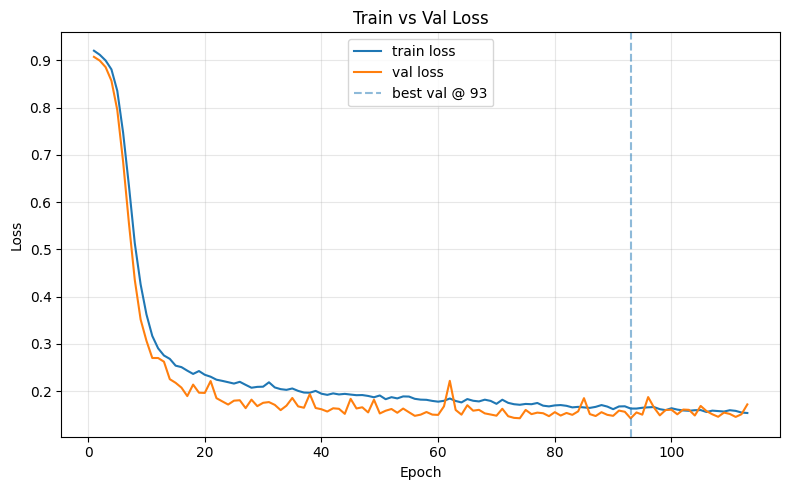

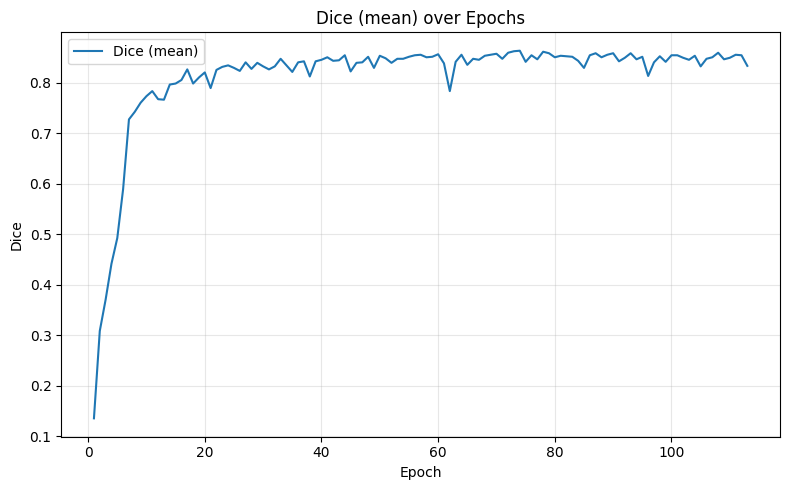

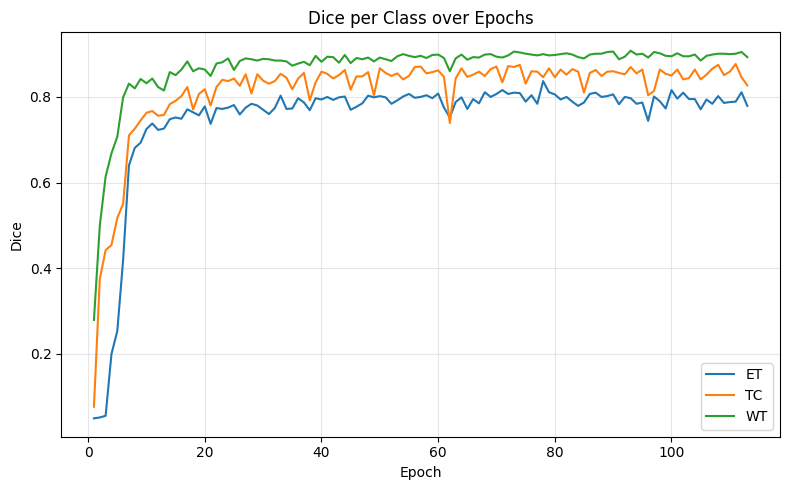

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ganti path sesuai lokasi file kamu
df = pd.read_csv("ReportHasil/UnetPP_warmupLR.csv").sort_values("epoch")

best_idx = df["val_loss"].idxmin()
best_epoch = int(df.loc[best_idx, "epoch"])

# Loss
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_loss"], label="train loss")
plt.plot(df["epoch"], df["val_loss"], label="val loss")
plt.axvline(best_epoch, linestyle="--", alpha=0.5, label=f"best val @ {best_epoch}")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train vs Val Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice (mean)
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_mean"], label="Dice (mean)")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice (mean) over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice per kelas
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_et"], label="ET")
plt.plot(df["epoch"], df["dice_tc"], label="TC")
plt.plot(df["epoch"], df["dice_wt"], label="WT")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice per Class over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


# Unet++ MedicalNet Warmup Freeze Encoder & Warmup LR decoder

In [1]:
import os, math, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, EnsureTyped, Compose, SelectItemsd,
    NormalizeIntensityd, CropForegroundd, RandSpatialCropd,
    RandScaleIntensityd, RandShiftIntensityd, RandFlipd, ConcatItemsd, MapTransform
)
from monai.inferers import sliding_window_inference

def log(*a): print(*a, flush=True)

PROJECT_ROOT = Path().resolve()                    # selevel notebook
DATA_ROOT    = PROJECT_ROOT / "data"
# --- KONFIG ---
MAIN_DIR   = DATA_ROOT  # ganti path sesuai datasetmu
BATCH_SIZE = 1                                  # aman di T4 dengan patch 128^3
NUM_WORKERS= 2
ROI = (128, 128, 128)

/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/module.py:396: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


In [2]:
import os
from pathlib import Path

PROJECT_ROOT = Path().resolve()
DATA_ROOT    = PROJECT_ROOT / "data"   # kamu bilang sekarang langsung "data"

def looks_like_patient_dir(p: Path) -> bool:
    if not p.is_dir(): return False
    need = ["flair","t1","t1ce","t2","seg"]
    found = 0
    for suf in need:
        if list(p.glob(f"*_{suf}.nii*")):
            found += 1
    return found == len(need)

def auto_find_main_dir(data_root: Path) -> str:
    # 1) data_root → apakah langsung berisi folder pasien?
    subs = [x for x in data_root.iterdir() if x.is_dir()]
    if any(looks_like_patient_dir(x) for x in subs):
        return str(data_root)
    # 2) satu tingkat di bawah
    for sub in subs:
        subs2 = [x for x in sub.iterdir() if x.is_dir()]
        if any(looks_like_patient_dir(x) for x in subs2):
            return str(sub)
    # 3) fallback: cari lebih dalam
    for sub in data_root.rglob("*"):
        if sub.is_dir():
            subs3 = [x for x in sub.iterdir() if x.is_dir()]
            if any(looks_like_patient_dir(x) for x in subs3):
                return str(sub)
    raise RuntimeError(f"Tidak menemukan folder pasien di bawah: {data_root}")

MAIN_DIR = auto_find_main_dir(DATA_ROOT)
print("MAIN_DIR =", MAIN_DIR)

# intip 1 folder pasien & isinya
sample_pat = next((d for d in Path(MAIN_DIR).iterdir() if d.is_dir()), None)
if sample_pat:
    print("Contoh folder pasien:", sample_pat.name)
    print("Contoh file:",
          [p.name for p in sample_pat.glob("*.nii*")])


MAIN_DIR = /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Contoh folder pasien: BraTS20_Training_115
Contoh file: ['BraTS20_Training_115_t1.nii', 'BraTS20_Training_115_seg.nii', 'BraTS20_Training_115_t2.nii', 'BraTS20_Training_115_flair.nii', 'BraTS20_Training_115_t1ce.nii']


In [3]:
def get_data_paths(data_dir):
    def find_file(folder, pid, suffix):
        for ext in (".nii.gz", ".nii"):
            p = os.path.join(folder, f"{pid}_{suffix}{ext}")
            if os.path.exists(p): return p
        return None

    data_paths = []
    print(f"Scanning dataset dir: {data_dir}")
    for pid in sorted(os.listdir(data_dir)):
        pdir = os.path.join(data_dir, pid)
        if not os.path.isdir(pdir): continue
        flair = find_file(pdir, pid, "flair")
        t1    = find_file(pdir, pid, "t1")
        t1gd  = find_file(pdir, pid, "t1ce")
        t2    = find_file(pdir, pid, "t2")
        seg   = find_file(pdir, pid, "seg")
        if all([flair, t1, t1gd, t2, seg]):
            data_paths.append({"flair":flair, "t1":t1, "t1gd":t1gd, "t2":t2, "label":seg, "pid":pid})
    print(f"Found {len(data_paths)} samples.")
    return data_paths

all_paths = get_data_paths(MAIN_DIR)
if not all_paths:
    raise RuntimeError("No data found. Check MAIN_DIR & filenames.")


Scanning dataset dir: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Found 368 samples.


In [4]:
class BraTSLabelToETTCWT(MapTransform):
    """
    Input d["label"] shape [1,D,H,W] atau [D,H,W] berisi {0,1,2,4}.
    Output d["label_ettcwt"] shape [3,D,H,W]: [ET, TC, WT] sebagai mask biner.
    """
    def __init__(self, keys=("label",), out_key="label_ettcwt"):
        super().__init__(keys); self.out_key = out_key

    def __call__(self, data):
        d = dict(data)
        lab = d[self.keys[0]]
        lab = torch.as_tensor(lab)
        if lab.ndim == 4 and lab.shape[0] == 1: lab = lab[0]  # [D,H,W]
        et = (lab == 4).float()
        tc = ((lab == 1) | (lab == 4)).float()
        wt = ((lab == 1) | (lab == 2) | (lab == 4)).float()
        d[self.out_key] = torch.stack([et, tc, wt], dim=0)  # [3,D,H,W]
        return d

In [5]:
P_RESCALE = 0.20
P_SHIFT   = 0.20
P_FLIP    = 0.50

train_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=True, random_size=False),
    # label → 3C multi-label
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
    # augmentasi B
    RandScaleIntensityd(keys="image", factors=0.1, prob=P_RESCALE),  # ×U[0.9,1.1]
    RandShiftIntensityd(keys="image", offsets=0.1, prob=P_SHIFT),    # +U[-0.1,0.1]
    RandFlipd(keys=["image","label_ettcwt"], prob=P_FLIP, spatial_axis=[0,1,2]),
])

val_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=False, random_size=False),
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
])


/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [6]:
class BraTSDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = list(items); self.tx = transform
        if not self.items: raise ValueError("Empty dataset")
    def __len__(self): return len(self.items)
    def __getitem__(self, i): 
        s = self.items[i]
        return self.tx(s) if self.tx else s

rng = np.random.RandomState(42)
perm = rng.permutation(len(all_paths))
all_paths = [all_paths[i] for i in perm]
cut = int(0.8*len(all_paths))
train_ds = BraTSDataset(all_paths[:cut], transform=train_transforms)
val_ds   = BraTSDataset(all_paths[cut:],  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

log(f"Loaders OK | train={len(train_ds)} val={len(val_ds)} bs={BATCH_SIZE}")

Loaders OK | train=294 val=74 bs=1


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F, re
import monai.networks.nets.resnet as monai_resnet
from monai.networks.layers.factories import Conv
from monai.networks.nets.basic_unet import TwoConv, UpCat

def prepare_medicalnet_state_for_monai(sd_in, in_channels=4):
    sd_raw = sd_in.get("state_dict", sd_in)
    sd = dict(sd_raw)
    remap = {}

    for k, v in sd.items():
        kk = k[len("module."):] if k.startswith("module.") else k

        # drop classifier
        if kk.startswith("fc."):
            continue

        # strip inner ".conv" (varian yang simpan conv submodule)
        kk = kk.replace(".conv1.conv.", ".conv1.")
        kk = kk.replace(".conv2.conv.", ".conv2.")
        kk = kk.replace(".conv3.conv.", ".conv3.")  # aman utk R50 juga

        # map style 'downsample.conv/bn' → 'downsample.0/1'
        kk = kk.replace(".downsample.conv.", ".downsample.0.")
        kk = kk.replace(".downsample.bn.",  ".downsample.1.")

        # map style 'shortcut' → 'downsample'
        kk = kk.replace(".shortcut.0.", ".downsample.0.")
        kk = kk.replace(".shortcut.1.", ".downsample.1.")

        # sebagian ckpt pakai 'downsample.weight' (tanpa .0) → asumsi conv
        if ".downsample.weight" in kk and ".downsample.0.weight" not in kk:
            kk = kk.replace(".downsample.weight", ".downsample.0.weight")
        if ".downsample.bias" in kk and ".downsample.0.bias" not in kk:
            kk = kk.replace(".downsample.bias", ".downsample.0.bias")

        remap[kk] = v

    # adapt conv1 Cin=1 → multi-modal (mis. 4)
    for conv1_key in ["conv1.weight", "conv1.conv.weight"]:
        if conv1_key in remap:
            w = remap[conv1_key]
            if w.ndim == 5 and w.shape[1] == 1 and in_channels > 1:
                w = w.mean(1, keepdim=True).repeat(1, in_channels, 1, 1, 1) / float(in_channels)
                remap[conv1_key] = w
                break

    return remap


@torch.no_grad()
def load_medicalnet_into_monai_resnet(backbone, pth_path, in_channels=4, verbose=True):
    raw = torch.load(pth_path, map_location="cpu")
    sd  = prepare_medicalnet_state_for_monai(raw, in_channels=in_channels)
    info = backbone.load_state_dict(sd, strict=False)
    try:
        missing, unexpected = info.missing_keys, info.unexpected_keys
    except AttributeError:
        missing, unexpected = info
    if verbose:
        monai_keys = backbone.state_dict()
        matched = sum(int(k in monai_keys and monai_keys[k].shape == sd[k].shape) for k in sd.keys())
        print(f"[MedicalNet→MONAI] matched={matched}  missing={len(missing)}  unexpected={len(unexpected)}")
    return info

# -----------------------------
# Encoder: MedicalNet ResNet18 (3D)
# taps: /4=/64ch, /8=/128ch, /16=/256ch, /32=/512ch
# -----------------------------
class MedicalNetResNet18Encoder(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.backbone = monai_resnet.resnet18(
            spatial_dims=3, n_input_channels=in_channels, pretrained=False, progress=False
        )
        self.layer1 = self.backbone.layer1
        self.layer2 = self.backbone.layer2
        self.layer3 = self.backbone.layer3
        self.layer4 = self.backbone.layer4

    @torch.no_grad()
    def load_medicalnet_pretrain(self, pth_path, in_channels=4):
        load_medicalnet_into_monai_resnet(
            backbone=self.backbone, pth_path=pth_path, in_channels=in_channels, verbose=True
        )

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = F.relu(x, inplace=True)
        s0 = x                 # <<< /2 tap (SEBELUM maxpool)
        x  = self.backbone.maxpool(x)
        s1 = self.layer1(x)    # /4
        s2 = self.layer2(s1)   # /8
        s3 = self.layer3(s2)   # /16
        # s4 = self.layer4(s3) # /32 (TIDAK dipakai di UNet++ 5-level)
        return s0, s1, s2, s3

# -----------------------------
# Decoder: UNet++ 3D (ringan, DS=ON, upsample=nontrainable)
# features: (F0,F1,F2,F3,F4,Fhead) — kecil agar muat T4
# -----------------------------
class UNetPP3D_Decoder(nn.Module):
    def __init__(
        self,
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
        features=(16,32,64,128,128,16),
        act=("LeakyReLU", {"negative_slope": 0.1, "inplace": True}),
        norm=("instance", {"affine": True}),
        dropout=0.0,
        upsample="nontrainable",
        enc_channels=(64,128,256,512),
        deep_supervision=True,
    ):
        super().__init__()
        self.deep_supervision = deep_supervision
        F0,F1,F2,F3,F4,Fhead = features
        Conv1x1 = lambda a,b: Conv["conv", spatial_dims](a, b, kernel_size=1, bias=False)

        self.conv_0_0 = TwoConv(spatial_dims, in_channels, F0, act, norm, True, dropout)

        self.enc_adapt1 = Conv1x1(enc_channels[0], F1)
        self.enc_adapt2 = Conv1x1(enc_channels[1], F2)
        self.enc_adapt3 = Conv1x1(enc_channels[2], F3)
        self.enc_adapt4 = Conv1x1(enc_channels[3], F4)

        self.upcat_0_1 = UpCat(spatial_dims, F1, F0, F0, act, norm, True, dropout, upsample, halves=False)
        self.upcat_1_1 = UpCat(spatial_dims, F2, F1, F1, act, norm, True, dropout, upsample)
        self.upcat_2_1 = UpCat(spatial_dims, F3, F2, F2, act, norm, True, dropout, upsample)
        self.upcat_3_1 = UpCat(spatial_dims, F4, F3, F3, act, norm, True, dropout, upsample)

        self.upcat_0_2 = UpCat(spatial_dims, F1, F0*2, F0, act, norm, True, dropout, upsample, halves=False)
        self.upcat_1_2 = UpCat(spatial_dims, F2, F1*2, F1, act, norm, True, dropout, upsample)
        self.upcat_2_2 = UpCat(spatial_dims, F3, F2*2, F2, act, norm, True, dropout, upsample)

        self.upcat_0_3 = UpCat(spatial_dims, F1, F0*3, F0, act, norm, True, dropout, upsample, halves=False)
        self.upcat_1_3 = UpCat(spatial_dims, F2, F1*3, F1, act, norm, True, dropout, upsample)

        self.upcat_0_4 = UpCat(spatial_dims, F1, F0*4, Fhead, act, norm, True, dropout, upsample, halves=False)

        self.final_conv_0_1 = Conv["conv", spatial_dims](F0,    out_channels, kernel_size=1)
        self.final_conv_0_2 = Conv["conv", spatial_dims](F0,    out_channels, kernel_size=1)
        self.final_conv_0_3 = Conv["conv", spatial_dims](F0,    out_channels, kernel_size=1)
        self.final_conv_0_4 = Conv["conv", spatial_dims](Fhead, out_channels, kernel_size=1)

    def forward(self, x, feats):
        # feats dari encoder ResNet18: s0(~ /2), s1(~ /4), s2(~ /8), s3(~ /16)
        s0, s1, s2, s3 = feats
    
        # adapt channel
        s0 = self.enc_adapt1(s0)
        s1 = self.enc_adapt2(s1)
        s2 = self.enc_adapt3(s2)
        s3 = self.enc_adapt4(s3)
    
        # --- NORMALISASI SPASIAL: pastikan tepat /2, /4, /8, /16 dr input ---
        x_0_0 = self.conv_0_0(x)         # /1 (dimensi sama dgn input)
        D, H, W = x_0_0.shape[2:]
        size_1  = (max(1, D // 2),  max(1, H // 2),  max(1, W // 2))   # /2
        size_2  = (max(1, D // 4),  max(1, H // 4),  max(1, W // 4))   # /4
        size_3  = (max(1, D // 8),  max(1, H // 8),  max(1, W // 8))   # /8
        size_4  = (max(1, D // 16), max(1, H // 16), max(1, W // 16))  # /16
    
        s0 = F.interpolate(s0, size=size_1, mode="trilinear", align_corners=False)
        s1 = F.interpolate(s1, size=size_2, mode="trilinear", align_corners=False)
        s2 = F.interpolate(s2, size=size_3, mode="trilinear", align_corners=False)
        s3 = F.interpolate(s3, size=size_4, mode="trilinear", align_corners=False)
    
        # --- UNet++ grid (DS ON) ---
        # level-1 (target /1): up(sample /2) + skip /1
        x_1_0 = s0
        x_0_1 = self.upcat_0_1(x_1_0, x_0_0)
    
        # level-2
        x_2_0 = s1
        x_1_1 = self.upcat_1_1(x_2_0, x_1_0)
        x_0_2 = self.upcat_0_2(x_1_1, torch.cat([x_0_0, x_0_1], dim=1))
    
        # level-3
        x_3_0 = s2
        x_2_1 = self.upcat_2_1(x_3_0, x_2_0)
        x_1_2 = self.upcat_1_2(x_2_1, torch.cat([x_1_0, x_1_1], dim=1))
        x_0_3 = self.upcat_0_3(x_1_2, torch.cat([x_0_0, x_0_1, x_0_2], dim=1))
    
        # level-4 (terdalam /16)
        x_4_0 = s3
        x_3_1 = self.upcat_3_1(x_4_0, x_3_0)
        x_2_2 = self.upcat_2_2(x_3_1, torch.cat([x_2_0, x_2_1], dim=1))
        x_1_3 = self.upcat_1_3(x_2_2, torch.cat([x_1_0, x_1_1, x_1_2], dim=1))
        x_0_4 = self.upcat_0_4(x_1_3, torch.cat([x_0_0, x_0_1, x_0_2, x_0_3], dim=1))
    
        y_0_1 = self.final_conv_0_1(x_0_1)
        y_0_2 = self.final_conv_0_2(x_0_2)
        y_0_3 = self.final_conv_0_3(x_0_3)
        y_0_4 = self.final_conv_0_4(x_0_4)

        if self.deep_supervision:
            return [y_0_4, y_0_3, y_0_2, y_0_1] if self.training else y_0_4
        else:
            return y_0_4
# -----------------------------
# Wrapper: UNet++ 3D + MedicalNet (ResNet18)
# -----------------------------
class UNetPP3D_MedicalNet(nn.Module):
    def __init__(self,
        in_channels=4,
        out_channels=3,                   # ET/TC/WT (multi-label → sigmoid di loss)
        features=(16,32,64,128,128,16),   # kecil, aman T4
        enc_channels=(64,128,256,512),    # taps ResNet18
    ):
        super().__init__()
        self.encoder = MedicalNetResNet18Encoder(in_channels=in_channels)
        self.decoder = UNetPP3D_Decoder(
            spatial_dims=3,
            in_channels=in_channels,
            out_channels=out_channels,
            features=features,
            enc_channels=enc_channels,
            upsample="nontrainable",
            deep_supervision=True,
        )

    def load_medicalnet(self, pth_path):
        self.encoder.load_medicalnet_pretrain(
            pth_path=pth_path,
            in_channels=self.encoder.backbone.conv1.in_channels,
        )

    def forward(self, x):
        feats = self.encoder(x)
        return self.decoder(x, feats)


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNetPP3D_MedicalNet(
        in_channels=4,            # FLAIR,T1,T1ce,T2
        out_channels=3,           # ET/TC/WT (multi-label → sigmoid di loss)
        features=(16,32,64,128,128,16),
        enc_channels=(64,64,128,256),  # kecilkan jika VRAM mepet: (32,64,128,256,256,32)
    ).to(device)

# path MedicalNet (.pth) dari "Models" Kaggle (pakai pencari kalau perlu)
PROJECT_ROOT = Path().resolve()  # folder tempat notebook berada
MEDNET_PTH   = PROJECT_ROOT / "Pretrained" / "resnet_18_23dataset.pth"
model.load_medicalnet(MEDNET_PTH)

[MedicalNet→MONAI] matched=102  missing=20  unexpected=0


/tmp/ipykernel_3800330/1873568722.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(pth_path, map_location="cpu")


In [9]:
# === setelah model di-instansiasi & (opsional) load bobot ===
# model = UNetPP3D_MedicalNet(...).cuda()
# model.load_medicalnet(MEDNET_PTH)

import torch
import torch.nn as nn

def init_identity_downsample(block_down, in_ch, out_ch, stride=2):
    """
    block_down: nn.Sequential(conv1x1, bn)
    Set conv 1x1 jadi 'copy channel' (diagonal) dgn stride sesuai, BN -> γ=1, β=0, running stats reset.
    """
    conv = block_down[0]; bn = block_down[1]
    assert isinstance(conv, nn.Conv3d) and isinstance(bn, (nn.BatchNorm3d, nn.SyncBatchNorm)), \
        "Ekspektasi downsample = [Conv3d, BatchNorm3d]"

    # nolkan dulu, lalu isi diagonal agar menyalin channel sebanyak min(in_ch, out_ch)
    nn.init.zeros_(conv.weight)
    if conv.bias is not None:
        nn.init.zeros_(conv.bias)
    c = min(in_ch, out_ch)
    with torch.no_grad():
        for i in range(c):
            conv.weight[i, i, 0, 0, 0] = 1.0

    # BN ke identitas
    nn.init.ones_(bn.weight)
    nn.init.zeros_(bn.bias)
    bn.running_mean.zero_()
    bn.running_var.fill_(1)

def reinit_missing_downsamples_resnet18(backbone):
    # R18 taps: layer2.0, layer3.0, layer4.0 masing-masing punya downsample (stride=2)
    init_identity_downsample(backbone.layer2[0].downsample, in_ch=64,  out_ch=128, stride=2)
    init_identity_downsample(backbone.layer3[0].downsample, in_ch=128, out_ch=256, stride=2)
    init_identity_downsample(backbone.layer4[0].downsample, in_ch=256, out_ch=512, stride=2)

# PANGGIL DI SINI (setelah load pretrained)
reinit_missing_downsamples_resnet18(model.encoder.backbone)

# (opsional) cepat cek satu nilai diagonal untuk memastikan terisi:
print("diag l2:", model.encoder.backbone.layer2[0].downsample[0].weight[0,0,0,0,0].item())


diag l2: 1.0


In [10]:
for m in model.encoder.backbone.modules():
    if isinstance(m, (nn.BatchNorm3d, nn.SyncBatchNorm)):
        m.eval()

In [11]:
def dice_per_region(pred_bin, lab_bin, eps=1e-6):
    # pred_bin & lab_bin: [B,3,D,H,W] biner
    dims = (0,2,3,4)
    inter = (pred_bin * lab_bin).sum(dim=dims)                  # [3]
    den   = pred_bin.sum(dim=dims) + lab_bin.sum(dim=dims)      # [3]
    return (2*inter + eps) / (den + eps)  

In [12]:
def multilabel_dice_loss(logits, target, eps=1e-6):
    """
    logits: [B,3,D,H,W] (raw), target: [B,3,D,H,W] (binary)
    """
    probs = torch.sigmoid(logits)
    dims = (0,2,3,4)
    inter = (probs*target).sum(dims)
    den   = probs.sum(dims) + target.sum(dims)
    dice  = (2*inter + eps) / (den + eps)   # per-channel
    return 1.0 - dice.mean()

def ds_loss(outputs, target):
    if isinstance(outputs, (list, tuple)):
        return torch.stack([multilabel_dice_loss(o, target) for o in outputs]).mean()
    return multilabel_dice_loss(outputs, target)

In [13]:
def split_wd(named_params):
    decay, no_decay = [], []
    for n,p in named_params:
        if not p.requires_grad: continue
        if p.ndim == 1 or n.endswith(".bias"):
            no_decay.append(p)      # norm & bias
        else:
            decay.append(p)
    return [{"params":decay, "weight_decay":1e-2},
            {"params":no_decay, "weight_decay":0.0}]

enc_groups = split_wd(model.encoder.named_parameters())
dec_groups = split_wd(model.decoder.named_parameters())

optimizer = torch.optim.AdamW(
    [
        {**enc_groups[0], "lr":1e-4},  # encoder w/ decay
        {**enc_groups[1], "lr":1e-4},  # encoder no-decay
        {**dec_groups[0], "lr":2e-4},  # decoder w/ decay
        {**dec_groups[1], "lr":2e-4},  # decoder no-decay
    ]
)

def make_cosine_freeze_then_decay(
    optimizer,
    max_epochs=200,
    enc_freeze_epochs=5,   # encoder freeze 5 epoch
    dec_warmup_epochs=5,   # decoder warm-up 5 epoch
):
    def cosine_after(start_epoch, epoch):
        t = (epoch - start_epoch) / float(max(1, max_epochs - start_epoch))
        t = min(max(t, 0.0), 1.0)
        return 0.5 * (1.0 + math.cos(math.pi * t))  # 1.0 di start_epoch, lalu turun

    # decoder: 0->1 linear selama warm-up, lalu cosine
    def dec_lambda(epoch):
        if dec_warmup_epochs and epoch < dec_warmup_epochs:
            return float(epoch + 1) / float(max(1, dec_warmup_epochs))
        start = dec_warmup_epochs if dec_warmup_epochs else 0
        return cosine_after(start, epoch)

    # encoder: 0 (freeze) s/d enc_freeze_epochs-1, lalu LANGSUNG cosine dari LR dasar
    def enc_lambda(epoch):
        if epoch < enc_freeze_epochs:
            return 0.0
        return cosine_after(enc_freeze_epochs, epoch)

    # urutan harus sama dg optimizer: [enc(wd), enc(no-wd), dec(wd), dec(no-wd)]
    lambdas = [enc_lambda, enc_lambda, dec_lambda, dec_lambda]
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambdas)

MAX_EPOCHS = 200
scheduler  = make_cosine_freeze_then_decay(
    optimizer,
    max_epochs=MAX_EPOCHS,
    enc_freeze_epochs=5,   # freeze encoder 5 epoch pertama
    dec_warmup_epochs=5    # decoder warm-up 5 epoch pertama
)


In [14]:
from tqdm import tqdm
import time

scaler = GradScaler(enabled=True)
device = "cuda"
early_patience = 20
best_val = float("inf"); bad = 0
best_state = None

# stabilkan BN encoder (batch kecil)
for m in model.encoder.modules():
    if isinstance(m, (torch.nn.BatchNorm3d, torch.nn.SyncBatchNorm)):
        m.eval()

for epoch in range(MAX_EPOCHS):
    model.train()
    tr = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [train]", leave=False)
    for batch in pbar:
        img = batch["image"].to(device, non_blocking=True)                 # [B,4,D,H,W]
        lab = batch["label_ettcwt"].to(device, non_blocking=True).float()  # [B,3,D,H,W]

        optimizer.zero_grad(set_to_none=True)
        with autocast(True):
            out = model(img)                   # list (train) saat model.train()
            loss = ds_loss(out, lab)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()

        tr += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    tr /= max(1, len(train_loader))

    # ---- validation (sliding window) ----
    # ---- validation (sliding window) ----
    model.eval()
    va = 0.0
    dice_sums = torch.zeros(3, device=device)  # akumulasi Dice ET/TC/WT
    n_batches  = 0
    
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [val]", leave=False)
    with torch.no_grad():
        for batch in pbar_val:
            img = batch["image"].to(device)
            lab = batch["label_ettcwt"].to(device).float()  # [B,3,D,H,W]
    
            with autocast(True):
                # NOTE: decoder kita saat eval() return SINGLE head → boleh langsung pakai predictor=model
                logits = sliding_window_inference(
                    img, roi_size=ROI, sw_batch_size=1,
                    predictor=model, overlap=0.5, mode="gaussian"
                )
                loss = multilabel_dice_loss(logits, lab)
            va += loss.item(); n_batches += 1
    
            # --- METRICS: Dice per region ---
            probs = torch.sigmoid(logits)
            pred_bin = (probs > 0.5).float()
            lab_bin  = (lab   > 0.5).float()
            dice_cls = dice_per_region(pred_bin, lab_bin)  # [ET,TC,WT]
            dice_sums += dice_cls
    
            # tampilkan di progress bar (mean sementara)
            dice_tmp = (dice_sums / n_batches).detach().cpu().tolist()
            pbar_val.set_postfix(val_loss=f"{loss.item():.4f}",
                                 dice=f"ET:{dice_tmp[0]:.3f}|TC:{dice_tmp[1]:.3f}|WT:{dice_tmp[2]:.3f}")
    
    va /= max(1, n_batches)
    
    # ringkas Dice epoch
    dice_mean_per_cls = (dice_sums / max(1, n_batches)).detach().cpu().tolist()  # [ET,TC,WT]
    dice_mean = float(sum(dice_mean_per_cls)/3.0)
    names = ["ET","TC","WT"]
    dice_str = " | ".join(f"{n}:{v:.3f}" for n,v in zip(names, dice_mean_per_cls))
    
    log(f"[{epoch+1:03d}/{MAX_EPOCHS}] train={tr:.4f}  val={va:.4f}  Dice(mean)={dice_mean:.3f} ({dice_str})")

    scheduler.step()

    if va < best_val - 1e-6:
        best_val = va; bad = 0
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= early_patience:
            log(f"Early stop at {epoch+1}, best val={best_val:.4f}")
            break

CKPT_DIR = Path().resolve() / "checkpoints"   # folder sejajar notebook
CKPT_DIR.mkdir(parents=True, exist_ok=True)

stamp = time.strftime("%Y%m%d-%H%M%S")
best_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_best_{stamp}.pt"
last_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_last_{stamp}.pt"

# simpan BEST (berdasarkan val loss)
if best_state is not None:
    model.load_state_dict(best_state, strict=True)
    torch.save(model.state_dict(), best_path)
    log("saved BEST:", str(best_path))

# simpan LAST (state setelah epoch terakhir) — opsional tapi berguna untuk resume cepat
torch.save(model.state_dict(), last_path)
log("saved LAST:", str(last_path))

# (opsional) simpan checkpoint lengkap utk resume (model+optim+sched+scaler)
full_ckpt_path = CKPT_DIR / f"checkpoint_full_{stamp}.pt"
torch.save({
    "epoch": epoch + 1,
    "best_val": best_val,
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
    "scaler": scaler.state_dict(),
}, full_ckpt_path)
log("saved FULL checkpoint:", str(full_ckpt_path))


/tmp/ipykernel_3800330/3686693971.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
Epoch 1/200 [train]:   0%|          | 0/294 [00:00<?, ?it/s]

/tmp/ipykernel_3800330/3686693971.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(True):
Epoch 1/200 [val]:   0%|          | 0/74 [00:00<?, ?it/s]                          /tmp/ipykernel_3800330/3686693971.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(True):
                                                                                                                    

[001/200] train=0.9229  val=0.9060  Dice(mean)=0.207 (ET:0.087 | TC:0.162 | WT:0.371)


[002/200] train=0.9120  val=0.8959  Dice(mean)=0.272 (ET:0.137 | TC:0.191 | WT:0.488)


[003/200] train=0.9004  val=0.8776  Dice(mean)=0.492 (ET:0.486 | TC:0.358 | WT:0.631)


...

[099/200] train=0.1660  val=0.1718  Dice(mean)=0.829 (ET:0.766 | TC:0.832 | WT:0.890)


[100/200] train=0.1636  val=0.1581  Dice(mean)=0.843 (ET:0.786 | TC:0.841 | WT:0.901)


[101/200] train=0.1621  val=0.1645  Dice(mean)=0.836 (ET:0.779 | TC:0.835 | WT:0.895)


[102/200] train=0.1622  val=0.1593  Dice(mean)=0.841 (ET:0.782 | TC:0.845 | WT:0.897)
Early stop at 102, best val=0.1476


saved BEST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints/unetpp_medicalnet_multilabel_best_20251013-224841.pt
saved LAST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints/unetpp_medicalnet_multilabel_last_20251013-224841.pt
saved FULL checkpoint: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints/checkpoint_full_20251013-224841.pt


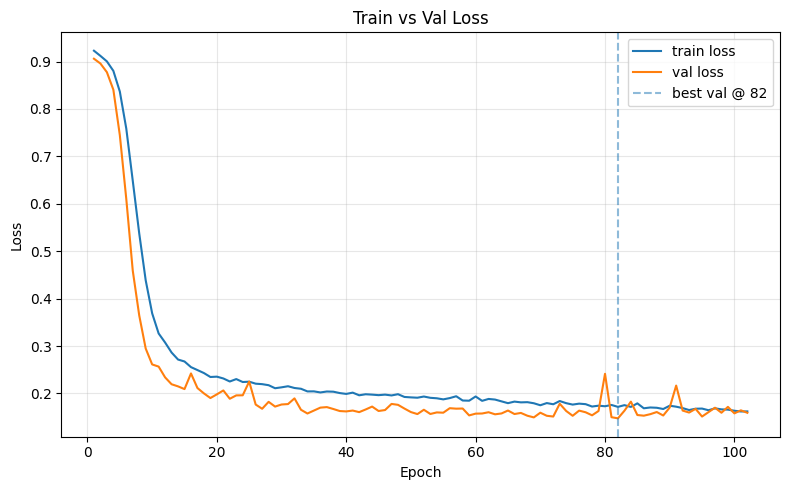

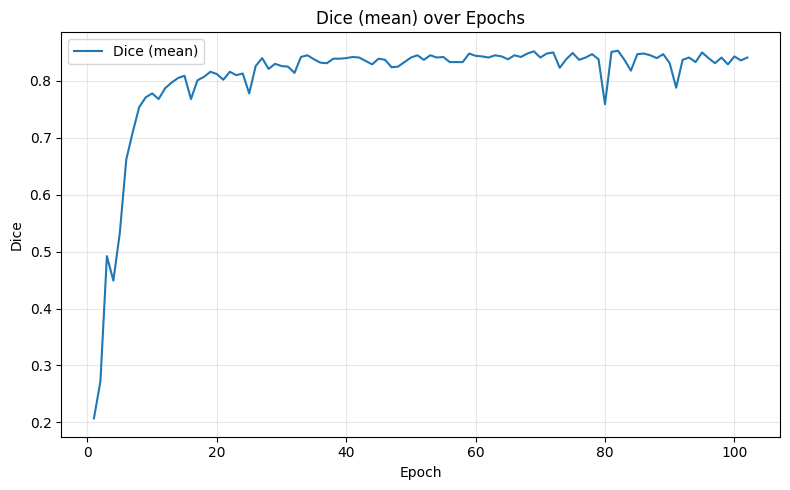

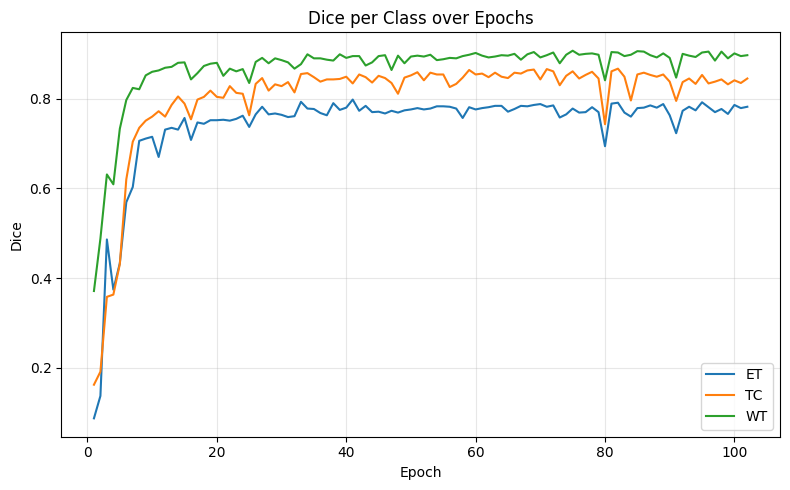

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ganti path sesuai lokasi file kamu
df = pd.read_csv("ReportHasil/UnetPP_warmupFreeze.csv").sort_values("epoch")

best_idx = df["val_loss"].idxmin()
best_epoch = int(df.loc[best_idx, "epoch"])

# Loss
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_loss"], label="train loss")
plt.plot(df["epoch"], df["val_loss"], label="val loss")
plt.axvline(best_epoch, linestyle="--", alpha=0.5, label=f"best val @ {best_epoch}")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train vs Val Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice (mean)
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_mean"], label="Dice (mean)")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice (mean) over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice per kelas
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_et"], label="ET")
plt.plot(df["epoch"], df["dice_tc"], label="TC")
plt.plot(df["epoch"], df["dice_wt"], label="WT")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice per Class over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


# Unet++ No Regulazation

In [1]:
import os, math, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, EnsureTyped, Compose, SelectItemsd,
    NormalizeIntensityd, CropForegroundd, RandSpatialCropd,
    RandScaleIntensityd, RandShiftIntensityd, RandFlipd, ConcatItemsd, MapTransform
)
from monai.inferers import sliding_window_inference

def log(*a): print(*a, flush=True)

PROJECT_ROOT = Path().resolve()                    # selevel notebook
DATA_ROOT    = PROJECT_ROOT / "data"
# --- KONFIG ---
MAIN_DIR   = DATA_ROOT  # ganti path sesuai datasetmu
BATCH_SIZE = 1                                  # aman di T4 dengan patch 128^3
NUM_WORKERS= 2
ROI = (128, 128, 128)

/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/module.py:396: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


In [2]:
import os
from pathlib import Path

PROJECT_ROOT = Path().resolve()
DATA_ROOT    = PROJECT_ROOT / "data"   # kamu bilang sekarang langsung "data"

def looks_like_patient_dir(p: Path) -> bool:
    if not p.is_dir(): return False
    need = ["flair","t1","t1ce","t2","seg"]
    found = 0
    for suf in need:
        if list(p.glob(f"*_{suf}.nii*")):
            found += 1
    return found == len(need)

def auto_find_main_dir(data_root: Path) -> str:
    # 1) data_root → apakah langsung berisi folder pasien?
    subs = [x for x in data_root.iterdir() if x.is_dir()]
    if any(looks_like_patient_dir(x) for x in subs):
        return str(data_root)
    # 2) satu tingkat di bawah
    for sub in subs:
        subs2 = [x for x in sub.iterdir() if x.is_dir()]
        if any(looks_like_patient_dir(x) for x in subs2):
            return str(sub)
    # 3) fallback: cari lebih dalam
    for sub in data_root.rglob("*"):
        if sub.is_dir():
            subs3 = [x for x in sub.iterdir() if x.is_dir()]
            if any(looks_like_patient_dir(x) for x in subs3):
                return str(sub)
    raise RuntimeError(f"Tidak menemukan folder pasien di bawah: {data_root}")

MAIN_DIR = auto_find_main_dir(DATA_ROOT)
print("MAIN_DIR =", MAIN_DIR)

# intip 1 folder pasien & isinya
sample_pat = next((d for d in Path(MAIN_DIR).iterdir() if d.is_dir()), None)
if sample_pat:
    print("Contoh folder pasien:", sample_pat.name)
    print("Contoh file:",
          [p.name for p in sample_pat.glob("*.nii*")])


MAIN_DIR = /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Contoh folder pasien: BraTS20_Training_115
Contoh file: ['BraTS20_Training_115_t1.nii', 'BraTS20_Training_115_seg.nii', 'BraTS20_Training_115_t2.nii', 'BraTS20_Training_115_flair.nii', 'BraTS20_Training_115_t1ce.nii']


In [3]:
def get_data_paths(data_dir):
    def find_file(folder, pid, suffix):
        for ext in (".nii.gz", ".nii"):
            p = os.path.join(folder, f"{pid}_{suffix}{ext}")
            if os.path.exists(p): return p
        return None

    data_paths = []
    print(f"Scanning dataset dir: {data_dir}")
    for pid in sorted(os.listdir(data_dir)):
        pdir = os.path.join(data_dir, pid)
        if not os.path.isdir(pdir): continue
        flair = find_file(pdir, pid, "flair")
        t1    = find_file(pdir, pid, "t1")
        t1gd  = find_file(pdir, pid, "t1ce")
        t2    = find_file(pdir, pid, "t2")
        seg   = find_file(pdir, pid, "seg")
        if all([flair, t1, t1gd, t2, seg]):
            data_paths.append({"flair":flair, "t1":t1, "t1gd":t1gd, "t2":t2, "label":seg, "pid":pid})
    print(f"Found {len(data_paths)} samples.")
    return data_paths

all_paths = get_data_paths(MAIN_DIR)
if not all_paths:
    raise RuntimeError("No data found. Check MAIN_DIR & filenames.")


Scanning dataset dir: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Found 368 samples.


In [4]:
class BraTSLabelToETTCWT(MapTransform):
    """
    Input d["label"] shape [1,D,H,W] atau [D,H,W] berisi {0,1,2,4}.
    Output d["label_ettcwt"] shape [3,D,H,W]: [ET, TC, WT] sebagai mask biner.
    """
    def __init__(self, keys=("label",), out_key="label_ettcwt"):
        super().__init__(keys); self.out_key = out_key

    def __call__(self, data):
        d = dict(data)
        lab = d[self.keys[0]]
        lab = torch.as_tensor(lab)
        if lab.ndim == 4 and lab.shape[0] == 1: lab = lab[0]  # [D,H,W]
        et = (lab == 4).float()
        tc = ((lab == 1) | (lab == 4)).float()
        wt = ((lab == 1) | (lab == 2) | (lab == 4)).float()
        d[self.out_key] = torch.stack([et, tc, wt], dim=0)  # [3,D,H,W]
        return d

In [5]:
P_RESCALE = 0.20
P_SHIFT   = 0.20
P_FLIP    = 0.50

train_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=True, random_size=False),
    # label → 3C multi-label
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
    # augmentasi B
    RandScaleIntensityd(keys="image", factors=0.1, prob=P_RESCALE),  # ×U[0.9,1.1]
    RandShiftIntensityd(keys="image", offsets=0.1, prob=P_SHIFT),    # +U[-0.1,0.1]
    RandFlipd(keys=["image","label_ettcwt"], prob=P_FLIP, spatial_axis=[0,1,2]),
])

val_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=False, random_size=False),
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
])


/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [15]:
class BraTSDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = list(items); self.tx = transform
        if not self.items: raise ValueError("Empty dataset")
    def __len__(self): return len(self.items)
    def __getitem__(self, i): 
        s = self.items[i]
        return self.tx(s) if self.tx else s

rng = np.random.RandomState(42)
perm = rng.permutation(len(all_paths))
all_paths = [all_paths[i] for i in perm]
cut = int(0.8*len(all_paths))
train_ds = BraTSDataset(all_paths[:cut], transform=train_transforms)
val_ds   = BraTSDataset(all_paths[cut:],  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

log(f"Loaders OK | train={len(train_ds)} val={len(val_ds)} bs={BATCH_SIZE}")

Loaders OK | train=294 val=74 bs=1


In [16]:
# ================================================
# UNet++ 3D + MedicalNet ResNet18 (Deep Supervision ON)
# Hemat VRAM (T4-friendly) — upsample=nontrainable, features kecil
# ================================================
import torch, torch.nn as nn, torch.nn.functional as F, re
import monai.networks.nets.resnet as monai_resnet
from monai.networks.layers.factories import Conv
from monai.networks.nets.basic_unet import TwoConv, UpCat

# -----------------------------
# Helper: remap & load weights
# -----------------------------
def prepare_medicalnet_state_for_monai(sd_in, in_channels=4):
    sd_raw = sd_in.get("state_dict", sd_in)
    sd = dict(sd_raw)
    remap = {}

    for k, v in sd.items():
        kk = k[len("module."):] if k.startswith("module.") else k

        # drop classifier
        if kk.startswith("fc."):
            continue

        # strip inner ".conv" (varian yang simpan conv submodule)
        kk = kk.replace(".conv1.conv.", ".conv1.")
        kk = kk.replace(".conv2.conv.", ".conv2.")
        kk = kk.replace(".conv3.conv.", ".conv3.")  # aman utk R50 juga

        # map style 'downsample.conv/bn' → 'downsample.0/1'
        kk = kk.replace(".downsample.conv.", ".downsample.0.")
        kk = kk.replace(".downsample.bn.",  ".downsample.1.")

        # map style 'shortcut' → 'downsample'
        kk = kk.replace(".shortcut.0.", ".downsample.0.")
        kk = kk.replace(".shortcut.1.", ".downsample.1.")

        # sebagian ckpt pakai 'downsample.weight' (tanpa .0) → asumsi conv
        if ".downsample.weight" in kk and ".downsample.0.weight" not in kk:
            kk = kk.replace(".downsample.weight", ".downsample.0.weight")
        if ".downsample.bias" in kk and ".downsample.0.bias" not in kk:
            kk = kk.replace(".downsample.bias", ".downsample.0.bias")

        remap[kk] = v

    # adapt conv1 Cin=1 → multi-modal (mis. 4)
    for conv1_key in ["conv1.weight", "conv1.conv.weight"]:
        if conv1_key in remap:
            w = remap[conv1_key]
            if w.ndim == 5 and w.shape[1] == 1 and in_channels > 1:
                w = w.mean(1, keepdim=True).repeat(1, in_channels, 1, 1, 1) / float(in_channels)
                remap[conv1_key] = w
                break

    return remap


@torch.no_grad()
def load_medicalnet_into_monai_resnet(backbone, pth_path, in_channels=4, verbose=True):
    raw = torch.load(pth_path, map_location="cpu")
    sd  = prepare_medicalnet_state_for_monai(raw, in_channels=in_channels)
    info = backbone.load_state_dict(sd, strict=False)
    try:
        missing, unexpected = info.missing_keys, info.unexpected_keys
    except AttributeError:
        missing, unexpected = info
    if verbose:
        monai_keys = backbone.state_dict()
        matched = sum(int(k in monai_keys and monai_keys[k].shape == sd[k].shape) for k in sd.keys())
        print(f"[MedicalNet→MONAI] matched={matched}  missing={len(missing)}  unexpected={len(unexpected)}")
    return info

# -----------------------------
# Encoder: MedicalNet ResNet18 (3D)
# taps: /4=/64ch, /8=/128ch, /16=/256ch, /32=/512ch
# -----------------------------
class MedicalNetResNet18Encoder(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.backbone = monai_resnet.resnet18(
            spatial_dims=3, n_input_channels=in_channels, pretrained=False, progress=False
        )
        self.layer1 = self.backbone.layer1
        self.layer2 = self.backbone.layer2
        self.layer3 = self.backbone.layer3
        self.layer4 = self.backbone.layer4

    @torch.no_grad()
    def load_medicalnet_pretrain(self, pth_path, in_channels=4):
        load_medicalnet_into_monai_resnet(
            backbone=self.backbone, pth_path=pth_path, in_channels=in_channels, verbose=True
        )

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = F.relu(x, inplace=True)
        s0 = x                 # <<< /2 tap (SEBELUM maxpool)
        x  = self.backbone.maxpool(x)
        s1 = self.layer1(x)    # /4
        s2 = self.layer2(s1)   # /8
        s3 = self.layer3(s2)   # /16
        # s4 = self.layer4(s3) # /32 (TIDAK dipakai di UNet++ 5-level)
        return s0, s1, s2, s3

# -----------------------------
# Decoder: UNet++ 3D (ringan, DS=ON, upsample=nontrainable)
# features: (F0,F1,F2,F3,F4,Fhead) — kecil agar muat T4
# -----------------------------
class UNetPP3D_Decoder(nn.Module):
    def __init__(
        self,
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
        features=(16,32,64,128,128,16),
        act=("LeakyReLU", {"negative_slope": 0.1, "inplace": True}),
        norm=("instance", {"affine": True}),
        dropout=0.0,
        upsample="nontrainable",
        enc_channels=(64,128,256,512),
        deep_supervision=True,
    ):
        super().__init__()
        self.deep_supervision = deep_supervision
        F0,F1,F2,F3,F4,Fhead = features
        Conv1x1 = lambda a,b: Conv["conv", spatial_dims](a, b, kernel_size=1, bias=False)

        self.conv_0_0 = TwoConv(spatial_dims, in_channels, F0, act, norm, True, dropout)

        self.enc_adapt1 = Conv1x1(enc_channels[0], F1)
        self.enc_adapt2 = Conv1x1(enc_channels[1], F2)
        self.enc_adapt3 = Conv1x1(enc_channels[2], F3)
        self.enc_adapt4 = Conv1x1(enc_channels[3], F4)

        self.upcat_0_1 = UpCat(spatial_dims, F1, F0, F0, act, norm, True, dropout, upsample, halves=False)
        self.upcat_1_1 = UpCat(spatial_dims, F2, F1, F1, act, norm, True, dropout, upsample)
        self.upcat_2_1 = UpCat(spatial_dims, F3, F2, F2, act, norm, True, dropout, upsample)
        self.upcat_3_1 = UpCat(spatial_dims, F4, F3, F3, act, norm, True, dropout, upsample)

        self.upcat_0_2 = UpCat(spatial_dims, F1, F0*2, F0, act, norm, True, dropout, upsample, halves=False)
        self.upcat_1_2 = UpCat(spatial_dims, F2, F1*2, F1, act, norm, True, dropout, upsample)
        self.upcat_2_2 = UpCat(spatial_dims, F3, F2*2, F2, act, norm, True, dropout, upsample)

        self.upcat_0_3 = UpCat(spatial_dims, F1, F0*3, F0, act, norm, True, dropout, upsample, halves=False)
        self.upcat_1_3 = UpCat(spatial_dims, F2, F1*3, F1, act, norm, True, dropout, upsample)

        self.upcat_0_4 = UpCat(spatial_dims, F1, F0*4, Fhead, act, norm, True, dropout, upsample, halves=False)

        self.final_conv_0_1 = Conv["conv", spatial_dims](F0,    out_channels, kernel_size=1)
        self.final_conv_0_2 = Conv["conv", spatial_dims](F0,    out_channels, kernel_size=1)
        self.final_conv_0_3 = Conv["conv", spatial_dims](F0,    out_channels, kernel_size=1)
        self.final_conv_0_4 = Conv["conv", spatial_dims](Fhead, out_channels, kernel_size=1)

    def forward(self, x, feats):
        # feats dari encoder ResNet18: s0(~ /2), s1(~ /4), s2(~ /8), s3(~ /16)
        s0, s1, s2, s3 = feats
    
        # adapt channel
        s0 = self.enc_adapt1(s0)
        s1 = self.enc_adapt2(s1)
        s2 = self.enc_adapt3(s2)
        s3 = self.enc_adapt4(s3)
    
        # --- NORMALISASI SPASIAL: pastikan tepat /2, /4, /8, /16 dr input ---
        x_0_0 = self.conv_0_0(x)         # /1 (dimensi sama dgn input)
        D, H, W = x_0_0.shape[2:]
        size_1  = (max(1, D // 2),  max(1, H // 2),  max(1, W // 2))   # /2
        size_2  = (max(1, D // 4),  max(1, H // 4),  max(1, W // 4))   # /4
        size_3  = (max(1, D // 8),  max(1, H // 8),  max(1, W // 8))   # /8
        size_4  = (max(1, D // 16), max(1, H // 16), max(1, W // 16))  # /16
    
        s0 = F.interpolate(s0, size=size_1, mode="trilinear", align_corners=False)
        s1 = F.interpolate(s1, size=size_2, mode="trilinear", align_corners=False)
        s2 = F.interpolate(s2, size=size_3, mode="trilinear", align_corners=False)
        s3 = F.interpolate(s3, size=size_4, mode="trilinear", align_corners=False)
    
        # --- UNet++ grid (DS ON) ---
        # level-1 (target /1): up(sample /2) + skip /1
        x_1_0 = s0
        x_0_1 = self.upcat_0_1(x_1_0, x_0_0)
    
        # level-2
        x_2_0 = s1
        x_1_1 = self.upcat_1_1(x_2_0, x_1_0)
        x_0_2 = self.upcat_0_2(x_1_1, torch.cat([x_0_0, x_0_1], dim=1))
    
        # level-3
        x_3_0 = s2
        x_2_1 = self.upcat_2_1(x_3_0, x_2_0)
        x_1_2 = self.upcat_1_2(x_2_1, torch.cat([x_1_0, x_1_1], dim=1))
        x_0_3 = self.upcat_0_3(x_1_2, torch.cat([x_0_0, x_0_1, x_0_2], dim=1))
    
        # level-4 (terdalam /16)
        x_4_0 = s3
        x_3_1 = self.upcat_3_1(x_4_0, x_3_0)
        x_2_2 = self.upcat_2_2(x_3_1, torch.cat([x_2_0, x_2_1], dim=1))
        x_1_3 = self.upcat_1_3(x_2_2, torch.cat([x_1_0, x_1_1, x_1_2], dim=1))
        x_0_4 = self.upcat_0_4(x_1_3, torch.cat([x_0_0, x_0_1, x_0_2, x_0_3], dim=1))
    
        y_0_1 = self.final_conv_0_1(x_0_1)
        y_0_2 = self.final_conv_0_2(x_0_2)
        y_0_3 = self.final_conv_0_3(x_0_3)
        y_0_4 = self.final_conv_0_4(x_0_4)

        if self.deep_supervision:
            return [y_0_4, y_0_3, y_0_2, y_0_1] if self.training else y_0_4
        else:
            return y_0_4
# -----------------------------
# Wrapper: UNet++ 3D + MedicalNet (ResNet18)
# -----------------------------
class UNetPP3D_MedicalNet(nn.Module):
    def __init__(self,
        in_channels=4,
        out_channels=3,                   # ET/TC/WT (multi-label → sigmoid di loss)
        features=(16,32,64,128,128,16),   # kecil, aman T4
        enc_channels=(64,128,256,512),    # taps ResNet18
    ):
        super().__init__()
        self.encoder = MedicalNetResNet18Encoder(in_channels=in_channels)
        self.decoder = UNetPP3D_Decoder(
            spatial_dims=3,
            in_channels=in_channels,
            out_channels=out_channels,
            features=features,
            enc_channels=enc_channels,
            upsample="nontrainable",
            deep_supervision=True,
        )

    def load_medicalnet(self, pth_path):
        self.encoder.load_medicalnet_pretrain(
            pth_path=pth_path,
            in_channels=self.encoder.backbone.conv1.in_channels,
        )

    def forward(self, x):
        feats = self.encoder(x)
        return self.decoder(x, feats)


In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNetPP3D_MedicalNet(
        in_channels=4,            # FLAIR,T1,T1ce,T2
        out_channels=3,           # ET/TC/WT (multi-label → sigmoid di loss)
        features=(16,32,64,128,128,16),
        enc_channels=(64,64,128,256),  # kecilkan jika VRAM mepet: (32,64,128,256,256,32)
    ).to(device)

# path MedicalNet (.pth) dari "Models" Kaggle (pakai pencari kalau perlu)
PROJECT_ROOT = Path().resolve()  # folder tempat notebook berada
MEDNET_PTH   = PROJECT_ROOT / "Pretrained" / "resnet_18_23dataset.pth"
model.load_medicalnet(MEDNET_PTH)

/tmp/ipykernel_154027/1873568722.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(pth_path, map_location="cpu")


[MedicalNet→MONAI] matched=102  missing=20  unexpected=0


In [18]:
# === setelah model di-instansiasi & (opsional) load bobot ===
# model = UNetPP3D_MedicalNet(...).cuda()
# model.load_medicalnet(MEDNET_PTH)

import torch
import torch.nn as nn

def init_identity_downsample(block_down, in_ch, out_ch, stride=2):
    """
    block_down: nn.Sequential(conv1x1, bn)
    Set conv 1x1 jadi 'copy channel' (diagonal) dgn stride sesuai, BN -> γ=1, β=0, running stats reset.
    """
    conv = block_down[0]; bn = block_down[1]
    assert isinstance(conv, nn.Conv3d) and isinstance(bn, (nn.BatchNorm3d, nn.SyncBatchNorm)), \
        "Ekspektasi downsample = [Conv3d, BatchNorm3d]"

    # nolkan dulu, lalu isi diagonal agar menyalin channel sebanyak min(in_ch, out_ch)
    nn.init.zeros_(conv.weight)
    if conv.bias is not None:
        nn.init.zeros_(conv.bias)
    c = min(in_ch, out_ch)
    with torch.no_grad():
        for i in range(c):
            conv.weight[i, i, 0, 0, 0] = 1.0

    # BN ke identitas
    nn.init.ones_(bn.weight)
    nn.init.zeros_(bn.bias)
    bn.running_mean.zero_()
    bn.running_var.fill_(1)

def reinit_missing_downsamples_resnet18(backbone):
    # R18 taps: layer2.0, layer3.0, layer4.0 masing-masing punya downsample (stride=2)
    init_identity_downsample(backbone.layer2[0].downsample, in_ch=64,  out_ch=128, stride=2)
    init_identity_downsample(backbone.layer3[0].downsample, in_ch=128, out_ch=256, stride=2)
    init_identity_downsample(backbone.layer4[0].downsample, in_ch=256, out_ch=512, stride=2)

# PANGGIL DI SINI (setelah load pretrained)
reinit_missing_downsamples_resnet18(model.encoder.backbone)

# (opsional) cepat cek satu nilai diagonal untuk memastikan terisi:
print("diag l2:", model.encoder.backbone.layer2[0].downsample[0].weight[0,0,0,0,0].item())


diag l2: 1.0


In [19]:
for m in model.encoder.backbone.modules():
    if isinstance(m, (nn.BatchNorm3d, nn.SyncBatchNorm)):
        m.eval()

In [20]:
def dice_per_region(pred_bin, lab_bin, eps=1e-6):
    # pred_bin & lab_bin: [B,3,D,H,W] biner
    dims = (0,2,3,4)
    inter = (pred_bin * lab_bin).sum(dim=dims)                  # [3]
    den   = pred_bin.sum(dim=dims) + lab_bin.sum(dim=dims)      # [3]
    return (2*inter + eps) / (den + eps)  

In [21]:
def multilabel_dice_loss(logits, target, eps=1e-6):
    """
    logits: [B,3,D,H,W] (raw), target: [B,3,D,H,W] (binary)
    """
    probs = torch.sigmoid(logits)
    dims = (0,2,3,4)
    inter = (probs*target).sum(dims)
    den   = probs.sum(dims) + target.sum(dims)
    dice  = (2*inter + eps) / (den + eps)   # per-channel
    return 1.0 - dice.mean()

def ds_loss(outputs, target):
    if isinstance(outputs, (list, tuple)):
        return torch.stack([multilabel_dice_loss(o, target) for o in outputs]).mean()
    return multilabel_dice_loss(outputs, target)

In [22]:
def split_wd(named_params):
    decay, no_decay = [], []
    for n,p in named_params:
        if not p.requires_grad: continue
        if p.ndim == 1 or n.endswith(".bias"):
            no_decay.append(p)      # norm & bias
        else:
            decay.append(p)
    return [{"params":decay, "weight_decay":1e-2},
            {"params":no_decay, "weight_decay":0.0}]

enc_groups = split_wd(model.encoder.named_parameters())
dec_groups = split_wd(model.decoder.named_parameters())

optimizer = torch.optim.AdamW(
    [
        {**enc_groups[0], "lr": 1e-4},  # encoder w/ decay
        {**enc_groups[1], "lr": 1e-4},  # encoder no-decay
        {**dec_groups[0], "lr": 2e-4},  # decoder w/ decay
        {**dec_groups[1], "lr": 2e-4},  # decoder no-decay
    ]
)
scheduler = None
MAX_EPOCHS = 200

In [ ]:
from tqdm import tqdm
import time

scaler = GradScaler(enabled=True)
device = "cuda"
early_patience = 20
best_val = float("inf"); bad = 0
best_state = None

# stabilkan BN encoder (batch kecil)
for m in model.encoder.modules():
    if isinstance(m, (torch.nn.BatchNorm3d, torch.nn.SyncBatchNorm)):
        m.eval()

for epoch in range(MAX_EPOCHS):
    model.train()
    tr = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [train]", leave=False)
    for batch in pbar:
        img = batch["image"].to(device, non_blocking=True)                 # [B,4,D,H,W]
        lab = batch["label_ettcwt"].to(device, non_blocking=True).float()  # [B,3,D,H,W]

        optimizer.zero_grad(set_to_none=True)
        with autocast(True):
            out = model(img)                   # list (train) saat model.train()
            loss = ds_loss(out, lab)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()

        tr += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    tr /= max(1, len(train_loader))

    # ---- validation (sliding window) ----
    # ---- validation (sliding window) ----
    model.eval()
    va = 0.0
    dice_sums = torch.zeros(3, device=device)  # akumulasi Dice ET/TC/WT
    n_batches  = 0
    
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [val]", leave=False)
    with torch.no_grad():
        for batch in pbar_val:
            img = batch["image"].to(device)
            lab = batch["label_ettcwt"].to(device).float()  # [B,3,D,H,W]
    
            with autocast(True):
                # NOTE: decoder kita saat eval() return SINGLE head → boleh langsung pakai predictor=model
                logits = sliding_window_inference(
                    img, roi_size=ROI, sw_batch_size=1,
                    predictor=model, overlap=0.5, mode="gaussian"
                )
                loss = multilabel_dice_loss(logits, lab)
            va += loss.item(); n_batches += 1
    
            # --- METRICS: Dice per region ---
            probs = torch.sigmoid(logits)
            pred_bin = (probs > 0.5).float()
            lab_bin  = (lab   > 0.5).float()
            dice_cls = dice_per_region(pred_bin, lab_bin)  # [ET,TC,WT]
            dice_sums += dice_cls
    
            # tampilkan di progress bar (mean sementara)
            dice_tmp = (dice_sums / n_batches).detach().cpu().tolist()
            pbar_val.set_postfix(val_loss=f"{loss.item():.4f}",
                                 dice=f"ET:{dice_tmp[0]:.3f}|TC:{dice_tmp[1]:.3f}|WT:{dice_tmp[2]:.3f}")
    
    va /= max(1, n_batches)
    
    # ringkas Dice epoch
    dice_mean_per_cls = (dice_sums / max(1, n_batches)).detach().cpu().tolist()  # [ET,TC,WT]
    dice_mean = float(sum(dice_mean_per_cls)/3.0)
    names = ["ET","TC","WT"]
    dice_str = " | ".join(f"{n}:{v:.3f}" for n,v in zip(names, dice_mean_per_cls))
    
    log(f"[{epoch+1:03d}/{MAX_EPOCHS}] train={tr:.4f}  val={va:.4f}  Dice(mean)={dice_mean:.3f} ({dice_str})")

    if scheduler is not None:
        scheduler.step()

    if va < best_val - 1e-6:
        best_val = va; bad = 0
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= early_patience:
            log(f"Early stop at {epoch+1}, best val={best_val:.4f}")
            break

CKPT_DIR = Path().resolve() / "checkpoints_UnetPP_raw"   # folder sejajar notebook
CKPT_DIR.mkdir(parents=True, exist_ok=True)

stamp = time.strftime("%Y%m%d-%H%M%S")
best_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_best_{stamp}.pt"
last_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_last_{stamp}.pt"

# simpan BEST (berdasarkan val loss)
if best_state is not None:
    model.load_state_dict(best_state, strict=True)
    torch.save(model.state_dict(), best_path)
    log("saved BEST:", str(best_path))

# simpan LAST (state setelah epoch terakhir) — opsional tapi berguna untuk resume cepat
torch.save(model.state_dict(), last_path)
log("saved LAST:", str(last_path))

# (opsional) simpan checkpoint lengkap utk resume (model+optim+sched+scaler)
full_ckpt_path = CKPT_DIR / f"checkpoint_full_{stamp}.pt"
torch.save({
    "epoch": epoch + 1,
    "best_val": best_val,
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "scaler": scaler.state_dict(),
}, full_ckpt_path)
log("saved FULL checkpoint:", str(full_ckpt_path))


/tmp/ipykernel_154027/510447380.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
Epoch 1/200 [train]:   0%|          | 0/294 [00:00<?, ?it/s]

/tmp/ipykernel_154027/510447380.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(True):
Epoch 1/200 [val]:   0%|          | 0/74 [00:00<?, ?it/s]                          /tmp/ipykernel_154027/510447380.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(True):
                                                                                                                    

[001/200] train=0.9120  val=0.8805  Dice(mean)=0.327 (ET:0.175 | TC:0.243 | WT:0.563)


[002/200] train=0.8851  val=0.8351  Dice(mean)=0.388 (ET:0.205 | TC:0.324 | WT:0.634)


[003/200] train=0.8460  val=0.7648  Dice(mean)=0.519 (ET:0.306 | TC:0.449 | WT:0.802)


...

[071/200] train=0.1877  val=0.1576  Dice(mean)=0.843 (ET:0.794 | TC:0.850 | WT:0.886)


[072/200] train=0.1772  val=0.1574  Dice(mean)=0.848 (ET:0.798 | TC:0.843 | WT:0.903)


[073/200] train=0.1774  val=0.1562  Dice(mean)=0.845 (ET:0.799 | TC:0.841 | WT:0.894)
Early stop at 73, best val=0.1501


saved BEST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_UnetPP_raw/unetpp_medicalnet_multilabel_best_20251015-001406.pt
saved LAST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_UnetPP_raw/unetpp_medicalnet_multilabel_last_20251015-001406.pt


AttributeError: 'NoneType' object has no attribute 'state_dict'

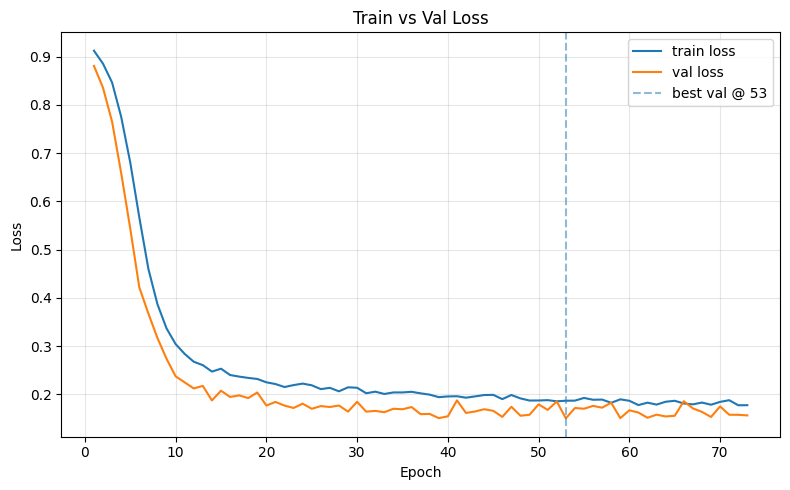

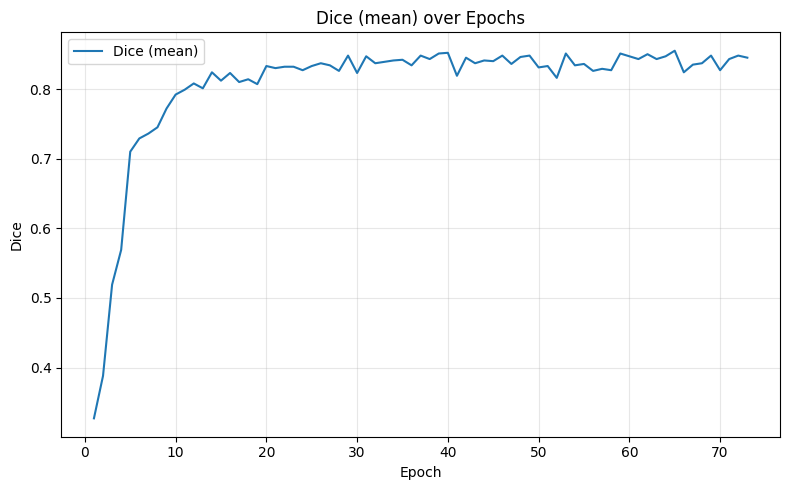

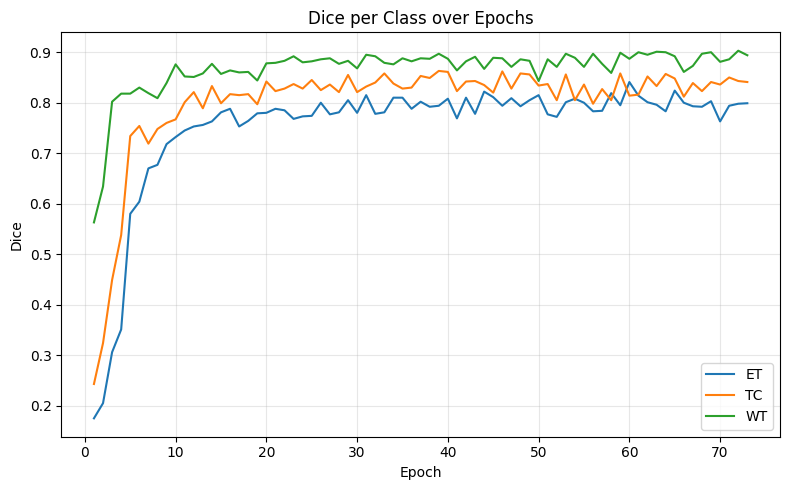

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ganti path sesuai lokasi file kamu
df = pd.read_csv("ReportHasil/UnetPP_raw.csv").sort_values("epoch")

best_idx = df["val_loss"].idxmin()
best_epoch = int(df.loc[best_idx, "epoch"])

# Loss
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_loss"], label="train loss")
plt.plot(df["epoch"], df["val_loss"], label="val loss")
plt.axvline(best_epoch, linestyle="--", alpha=0.5, label=f"best val @ {best_epoch}")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train vs Val Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice (mean)
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_mean"], label="Dice (mean)")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice (mean) over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice per kelas
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_et"], label="ET")
plt.plot(df["epoch"], df["dice_tc"], label="TC")
plt.plot(df["epoch"], df["dice_wt"], label="WT")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice per Class over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
